Literature Review – Telco Customer Churn Dataset
-


Customer churn refers to the situation where customers stop using a company’s services. In the telecommunications industry, churn prediction is considered one of the most important business problems because acquiring a new customer is usually more expensive than retaining an existing one.

The Telco Customer Churn dataset is widely used for Exploratory Data Analysis (EDA), machine learning, and customer behavior analysis. The dataset contains demographic information, service subscription details, billing information, and customer churn status.

Objective of the Dataset
-

The main objective of this dataset is to:

- Understand customer behavior
- Identify factors influencing churn
- Predict which customers are likely to leave the company
- Improve customer retention strategies

The target variable in this dataset is:

***Churn***

Where:

- Yes = Customer left the company
- No = Customer stayed with the company

In [16]:
#  Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [17]:
#  Load data
df = pd.read_csv('telcom_churndataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
#  First-pass inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
#  Summary statistics – look for impossibilities
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [20]:
# For checking features/columns 
print("Features/Columns:")
print(df.columns)

Features/Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [21]:
# Check total duplicate rows
df.duplicated().sum()

np.int64(0)

We have notice errors in some columns:
-
  - Blank space in 'TotalCharges' columns.


We need to remove these rows.

In [22]:
# Check number of blank-space rows in each column

blank_spaces = (df.astype(str)
                .apply(lambda x: x.str.strip() == '')
                .sum())

print("Blank space count in each column:\n")
print(blank_spaces[blank_spaces > 0])

Blank space count in each column:

TotalCharges    11
dtype: int64


In [23]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

df.dropna(inplace=True)

The MultipleLines feature provides limited additional information because it is directly dependent on the PhoneService column.

So, we can remove it. Removing this feature helps simplify the dataset and improves data preprocessing efficiency.

In [24]:
df.drop('MultipleLines', axis=1, inplace=True)

In [25]:
# After cleaning the shape of dataset
df.shape

(7032, 20)

In [26]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Univariate Analysis  – Telco Churn Dataset
--

### Churn Distribution

C:\Users\panka\AppData\Local\Temp\ipykernel_21332\3688669925.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


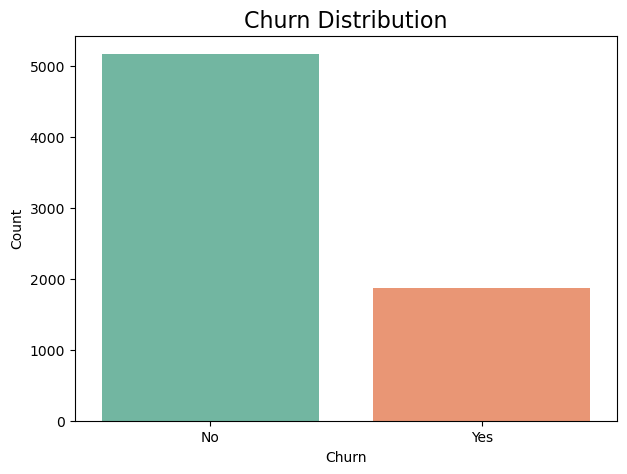

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Churn',
    data=df,
    palette='Set2'
)

plt.title('Churn Distribution', fontsize=16)
plt.xlabel('Churn')
plt.ylabel('Count')

plt.show()

- Most customers have not churned.
- However, the number of churned customers is still significant.
- Customer retention is an important business concern.

### Contract Type Distribution

C:\Users\panka\AppData\Local\Temp\ipykernel_21332\2696468020.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


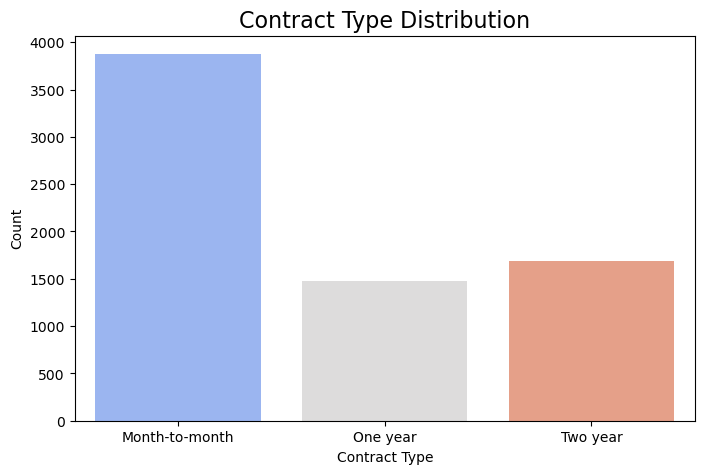

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    data=df,
    palette='coolwarm'
)

plt.title('Contract Type Distribution', fontsize=16)
plt.xlabel('Contract Type')
plt.ylabel('Count')

plt.show()

- Month-to-month contracts dominate the dataset.
- Long-term contracts are less common.
- Customers prefer flexible subscription plans.

### Internet Service Distribution

C:\Users\panka\AppData\Local\Temp\ipykernel_21332\2165482763.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


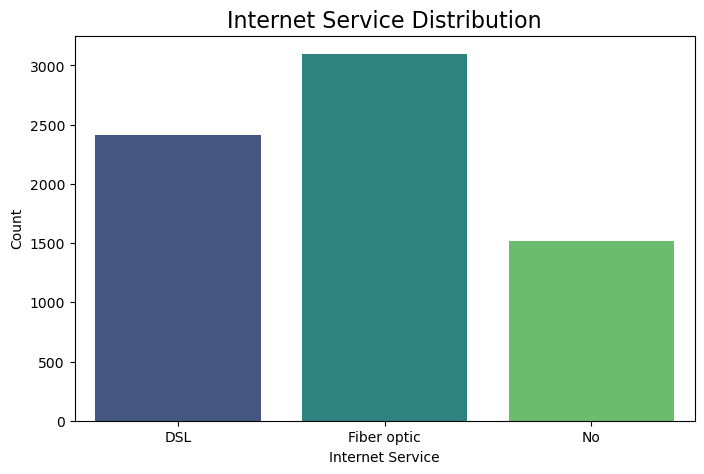

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    data=df,
    palette='viridis'
)

plt.title('Internet Service Distribution', fontsize=16)
plt.xlabel('Internet Service')
plt.ylabel('Count')

plt.show()

- Fiber optic and DSL are the most commonly used internet services.
- A smaller group of customers does not use internet service.
- Internet connectivity is a core service for most customers.

### Tenure Analysis

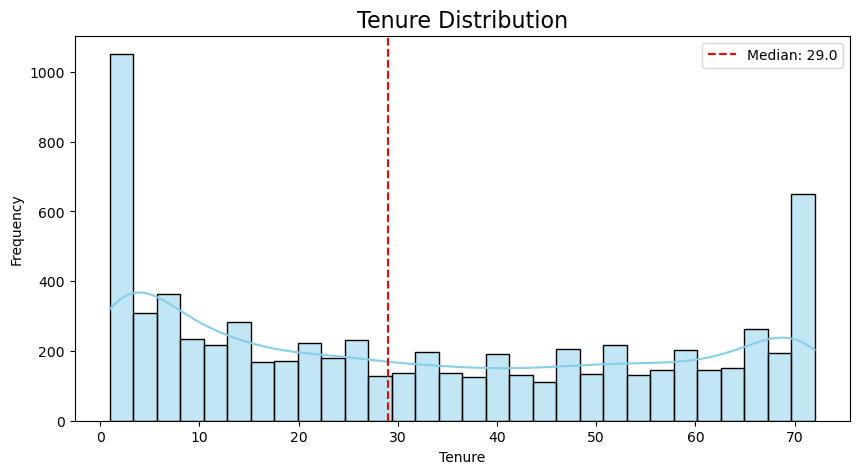

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['tenure'],
    bins=30,
    kde=True,
    color='skyblue'
)

median_value = df['tenure'].median()

plt.axvline(
    median_value,
    color='red',
    linestyle='--',
    label=f'Median: {median_value}'
)

plt.title('Tenure Distribution', fontsize=16)
plt.xlabel('Tenure')
plt.ylabel('Frequency')

plt.legend()

plt.show()

- Many customers are relatively new to the company.
- A noticeable number of long-term loyal customers also exist.
- The customer base contains both short-term and long-term users.

### Payment Method Distribution

C:\Users\panka\AppData\Local\Temp\ipykernel_21332\4230321290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


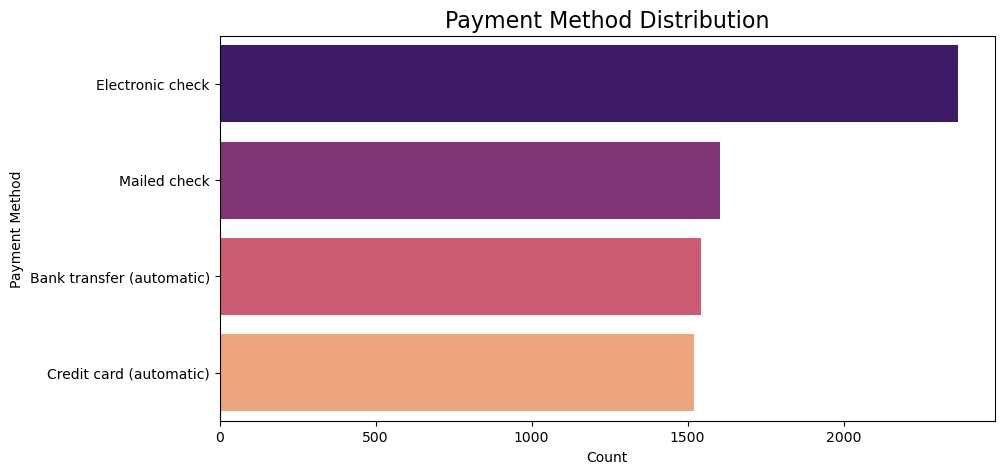

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='PaymentMethod',
    data=df,
    palette='magma'
)

plt.title('Payment Method Distribution', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Payment Method')

plt.show()

- Electronic check is the most commonly used payment method.
- Automatic payment methods are also widely adopted.
- Customers show diverse payment preferences.

### Monthly Charges Distribution

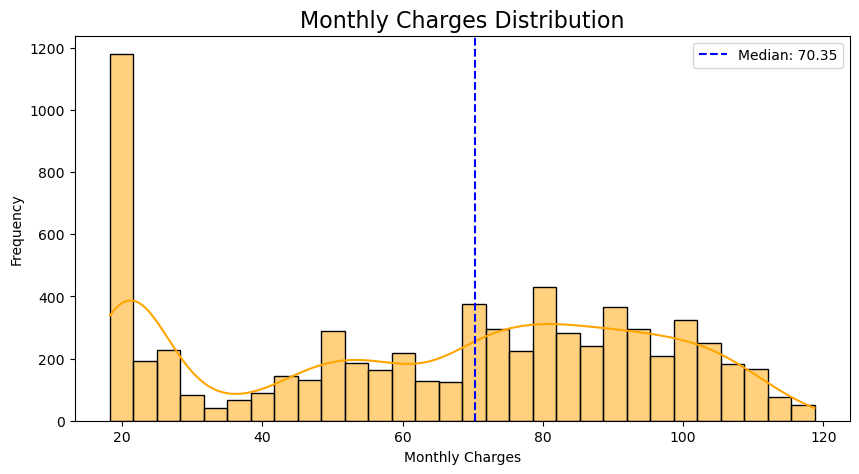

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['MonthlyCharges'],
    bins=30,
    kde=True,
    color='orange'
)

median_value = df['MonthlyCharges'].median()

plt.axvline(
    median_value,
    color='blue',
    linestyle='--',
    label=f'Median: {median_value:.2f}'
)

plt.title('Monthly Charges Distribution', fontsize=16)
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')

plt.legend()

plt.show()



* Monthly charges are distributed across a wide range of values.
* Most customers are paying lower monthly charges around 20–30.
* Another large group of customers is paying higher charges between 70–100.
* The distribution is not perfectly normal and shows multiple peaks.
* The median monthly charge is around 70.35.
* Customer pricing appears to be divided into different service plans.
* Higher monthly charges may indicate customers using premium services.
* Lower monthly charges may represent basic or limited service users.


### Total Charges Distribution

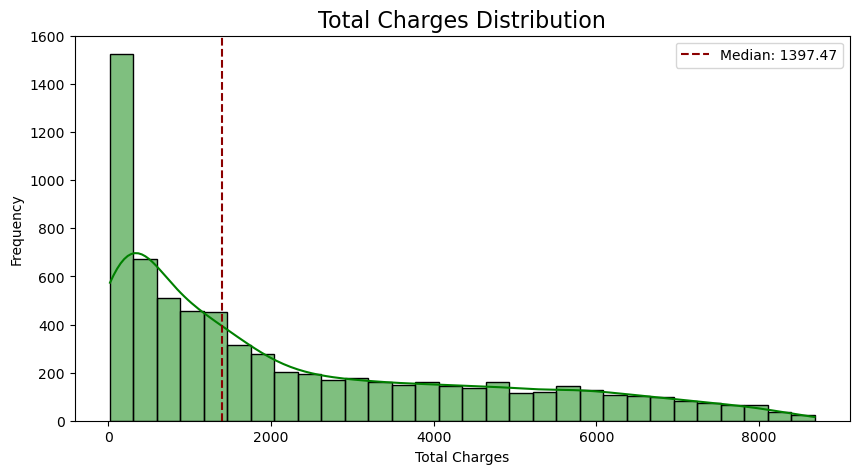

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['TotalCharges'],
    bins=30,
    kde=True,
    color='green'
)

median_value = df['TotalCharges'].median()

plt.axvline(
    median_value,
    color='darkred',
    linestyle='--',
    label=f'Median: {median_value:.2f}'
)

plt.title('Total Charges Distribution', fontsize=16)
plt.xlabel('Total Charges')
plt.ylabel('Frequency')

plt.legend()

plt.show()

- Most customers have lower total charges.
- The distribution is positively skewed (right-skewed).
- A small number of customers have very high total charges.
- The median total charge is around 1397.47.

### Monthly Charges Boxplot

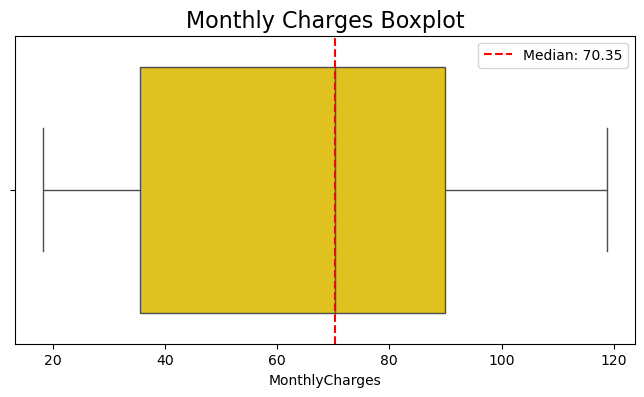

In [34]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['MonthlyCharges'],
    color='gold'
)

median_value = df['MonthlyCharges'].median()

plt.axvline(
    median_value,
    color='red',
    linestyle='--',
    label=f'Median: {median_value:.2f}'
)

plt.title('Monthly Charges Boxplot', fontsize=16)

plt.legend()

plt.show()

* Monthly charges are widely distributed among customers.
* The median monthly charge is around 70.35.
* Most customers fall within the medium charge range.
* No significant outliers are present in the data.
* Customers appear to use different service pricing plans.


### Total Charges Boxplot

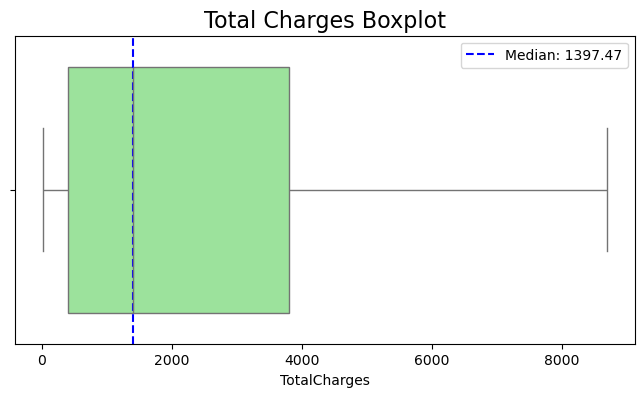

In [35]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['TotalCharges'],
    color='lightgreen'
)

median_value = df['TotalCharges'].median()

plt.axvline(
    median_value,
    color='blue',
    linestyle='--',
    label=f'Median: {median_value:.2f}'
)

plt.title('Total Charges Boxplot', fontsize=16)

plt.legend()

plt.show()

### Observations

* Total charges are spread over a very wide range.
* The median total charge is around 1397.47.
* Most customers have lower to medium total charges.
* No major outliers are visible in the dataset.
* Higher total charges likely belong to long-term customers.


Bivariate Analysis
--

### Churn vs Monthly Charges

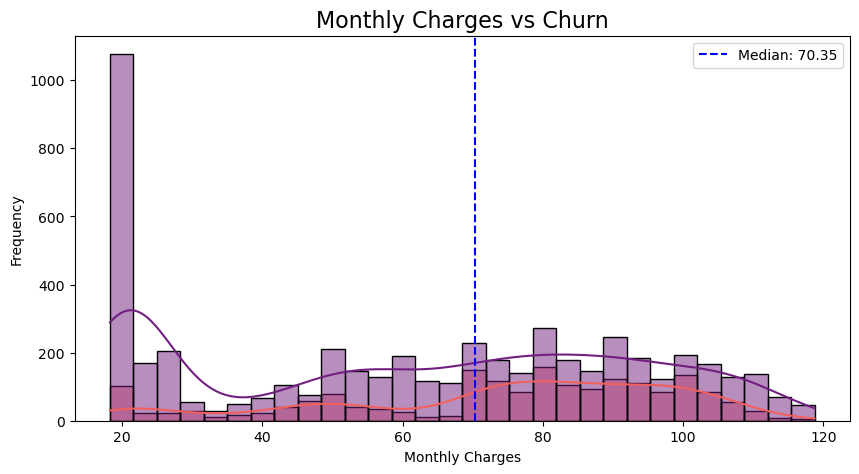

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    kde=True,
    bins=30,
    palette='magma'
)

median_value = df['MonthlyCharges'].median()

plt.axvline(
    median_value,
    color='blue',
    linestyle='--',
    label=f'Median: {median_value:.2f}'
)

plt.title('Monthly Charges vs Churn', fontsize=16)
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')

plt.legend()

plt.show()

- Customers with higher monthly charges show higher churn behavior.
- Lower charge customers are relatively more retained.
- Pricing may influence customer satisfaction.

### Churn vs Tenure

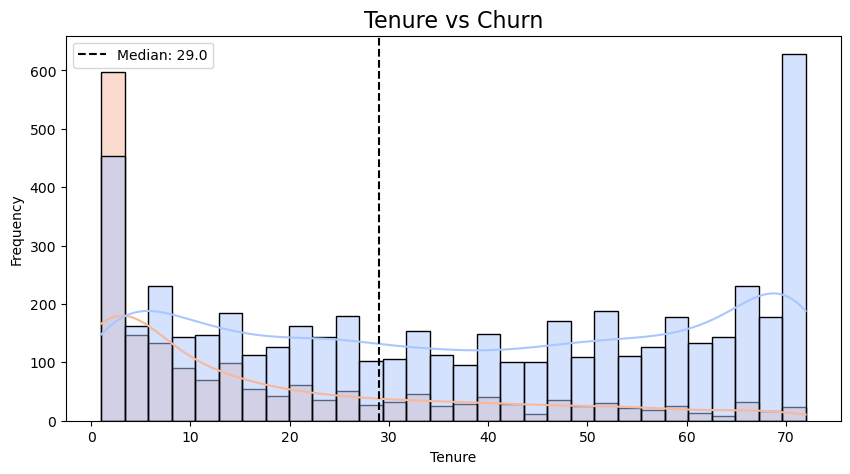

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True,
    bins=30,
    palette='coolwarm'
)

median_value = df['tenure'].median()

plt.axvline(
    median_value,
    color='black',
    linestyle='--',
    label=f'Median: {median_value}'
)

plt.title('Tenure vs Churn', fontsize=16)
plt.xlabel('Tenure')
plt.ylabel('Frequency')

plt.legend()

plt.show()

- Customers with lower tenure are more likely to churn.
- Long-term customers tend to stay with the company.
- Customer loyalty increases with tenure.

### Contract Type vs Monthly Charges

C:\Users\panka\AppData\Local\Temp\ipykernel_21332\3488646469.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


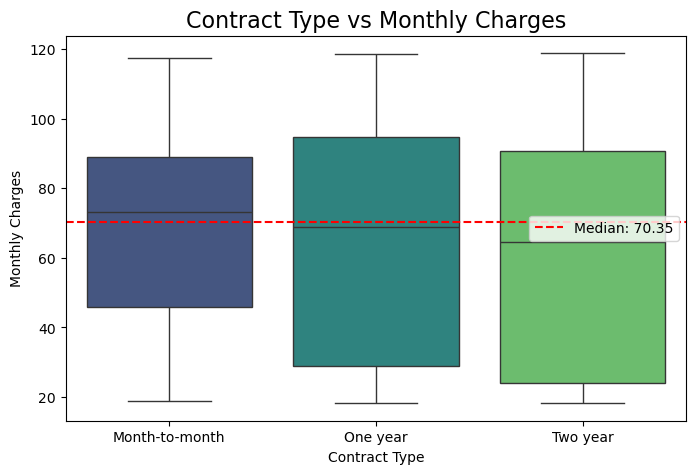

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Contract',
    y='MonthlyCharges',
    data=df,
    palette='viridis'
)

median_value = df['MonthlyCharges'].median()

plt.axhline(
    median_value,
    color='red',
    linestyle='--',
    label=f'Median: {median_value:.2f}'
)

plt.title('Contract Type vs Monthly Charges', fontsize=16)
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges')

plt.legend()

plt.show()

- Customers with Month-to-month contracts generally have slightly higher monthly charges
- One-year and Two-year contracts show a wider spread of charges
- The red dashed line shows the overall median monthly charge (~70.35)

### Contract vs Churn

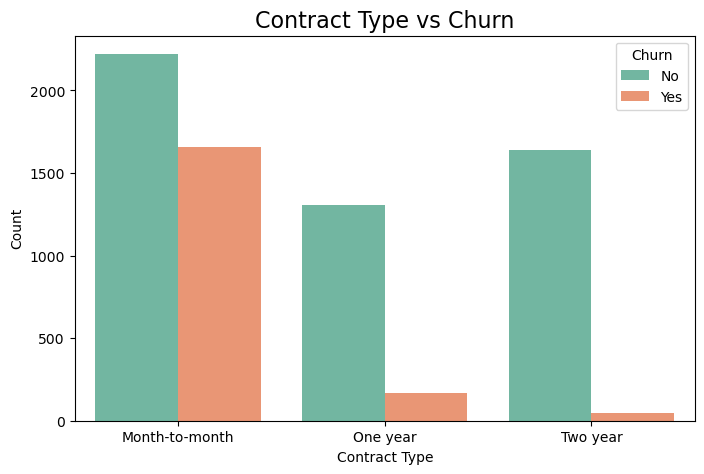

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df,
    palette='Set2'
)

plt.title('Contract Type vs Churn', fontsize=16)
plt.xlabel('Contract Type')
plt.ylabel('Count')

plt.show()

- Month-to-month customers have the highest churn rate.
- Customers with one-year and two-year contracts are more stable.
- Long-term contracts improve customer retention.

### Internet Service vs Churn

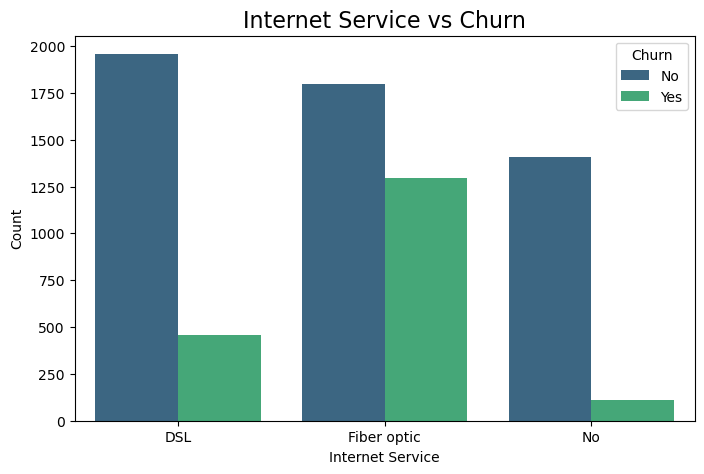

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df,
    palette='viridis'
)

plt.title('Internet Service vs Churn', fontsize=16)
plt.xlabel('Internet Service')
plt.ylabel('Count')

plt.show()

- Fiber optic users show higher churn compared to DSL users.
- Customers without internet service have the lowest churn.
- Service type appears to influence customer retention.

Multivariate Analysis
--

1. Contract Type, Internet Service & Churn
--

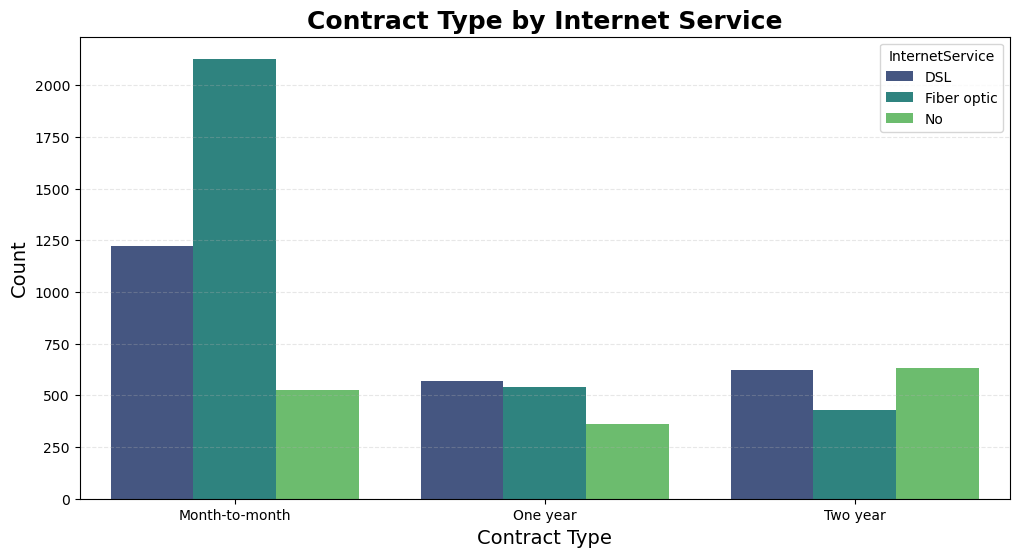

In [42]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='Contract',
    hue='InternetService',
    data=df,
    palette='viridis'
)

plt.title('Contract Type by Internet Service', fontsize=18, fontweight='bold')
plt.xlabel('Contract Type', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Detailed Observations
--
- Month-to-month contracts dominate across all internet service categories.
- Fiber optic customers are highly concentrated in month-to-month contracts, indicating that many premium internet users prefer flexible plans.
- DSL users are more evenly distributed between month-to-month and long-term contracts.
- Customers without internet service mostly appear in long-term contracts, suggesting greater service stability.
- Long-term contract customers are fewer overall, which may indicate customers prefer short-term flexibility over commitment.
- The graph suggests that internet service type and contract duration together may strongly influence churn behavior.

2. Monthly Charges by Contract Type and Churn
--


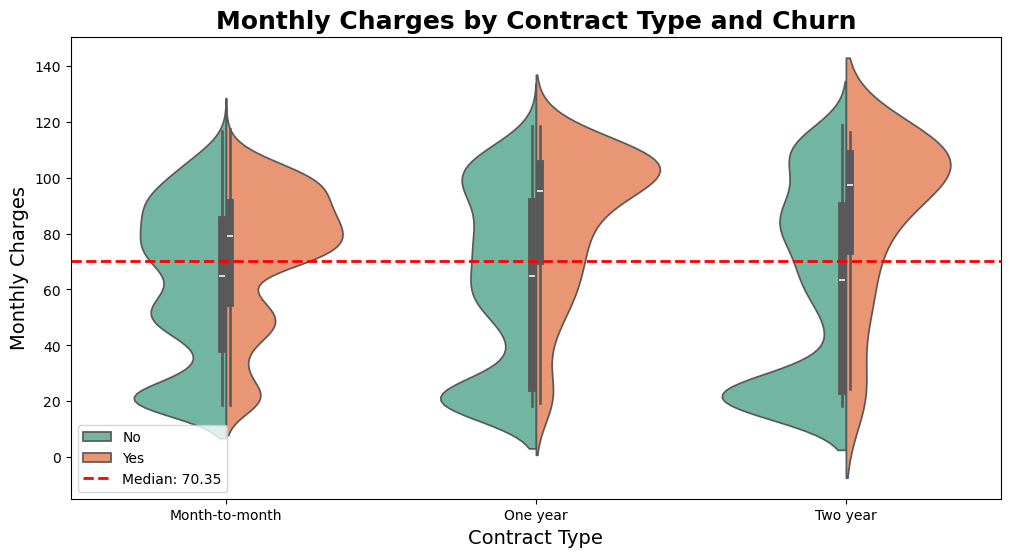

In [44]:

plt.figure(figsize=(12,6))

sns.violinplot(
    x='Contract',
    y='MonthlyCharges',
    hue='Churn',
    data=df,
    palette='Set2',
    split=True
)

median_value = df['MonthlyCharges'].median()

plt.axhline(
    median_value,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Median: {median_value:.2f}'
)

plt.title('Monthly Charges by Contract Type and Churn', fontsize=18, fontweight='bold')
plt.xlabel('Contract Type', fontsize=14)
plt.ylabel('Monthly Charges', fontsize=14)

plt.legend()

plt.show()

Monthly Charges by Contract Type and Churn Detailed Observations
--
- Customers who churn generally have higher monthly charges compared to retained customers.
- Month-to-month customers show the widest variation in monthly charges, indicating multiple pricing plans within short-term subscriptions.
- The density of churned customers increases noticeably at higher monthly charge ranges.
- One-year and two-year contract customers appear more stable with comparatively consistent pricing distributions.
- Long-term contract users with similar charges churn less frequently, suggesting contract commitment improves retention.
- Higher pricing combined with short-term contracts may increase customer dissatisfaction and churn probability.

3. Tenure Distribution by Internet Service
--

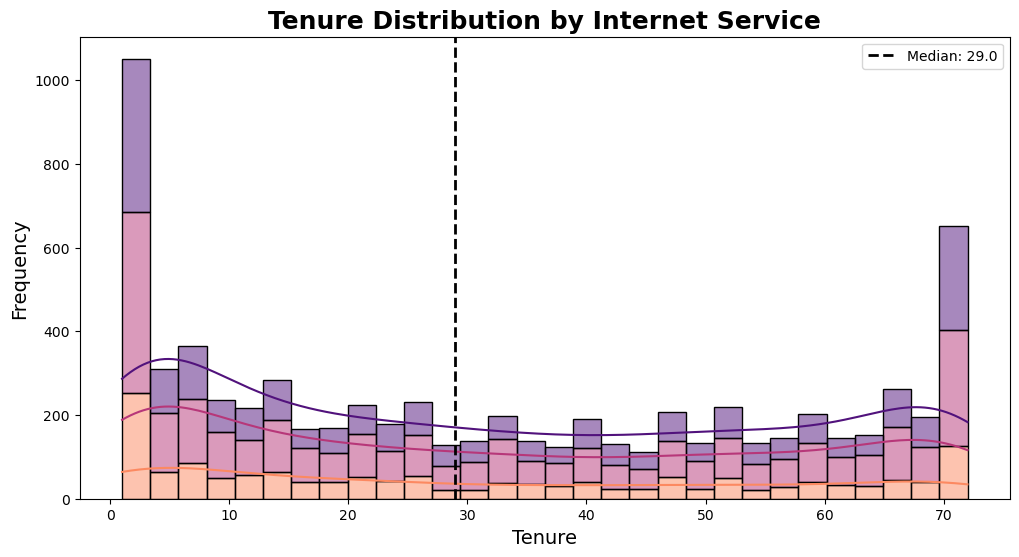

In [45]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='tenure',
    hue='InternetService',
    kde=True,
    multiple='stack',
    bins=30,
    palette='magma'
)

median_value = df['tenure'].median()

plt.axvline(
    median_value,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Median: {median_value}'
)

plt.title('Tenure Distribution by Internet Service', fontsize=18, fontweight='bold')
plt.xlabel('Tenure', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.legend()

plt.show()

 Tenure Distribution by Internet Service Detailed Observations
 --
- A large number of fiber optic customers fall into lower tenure ranges, indicating many are relatively new customers.
- DSL customers appear more evenly spread across both low and high tenure values.
- Customers without internet service tend to show higher tenure stability.
- The graph indicates that customer retention improves significantly as tenure increases.
- Low-tenure customers are more vulnerable to churn because customer-company relationships are not yet strongly established.
- High-tenure customers likely represent loyal customers who are satisfied with the service quality.

4. Payment Method by Contract Type
 --

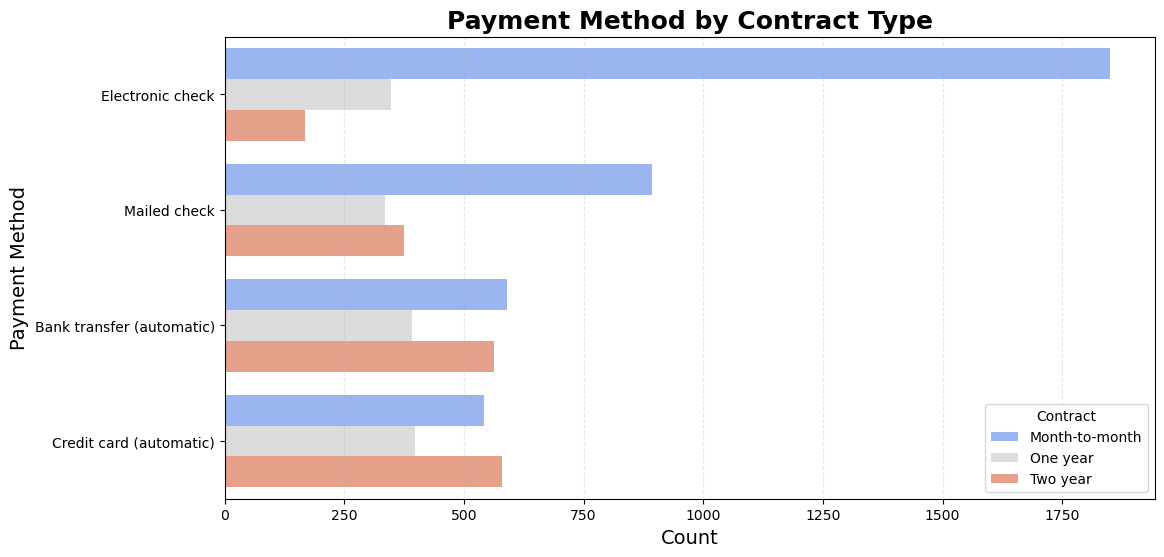

In [46]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='PaymentMethod',
    hue='Contract',
    data=df,
    palette='coolwarm'
)

plt.title('Payment Method by Contract Type', fontsize=18, fontweight='bold')
plt.xlabel('Count', fontsize=14)
plt.ylabel('Payment Method', fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

Payment Method by Contract Type Detailed Observations
--
- Electronic check is the most commonly used payment method among month-to-month customers.
- Customers using automatic bank transfer or credit card payments are more commonly associated with long-term contracts.
- Long-term customers appear to prefer automated and stable payment systems.
- Manual payment methods are more frequent among short-term customers.
- Payment behavior may reflect customer trust, convenience preference, and subscription stability.

5. Correlation Heatmap
--

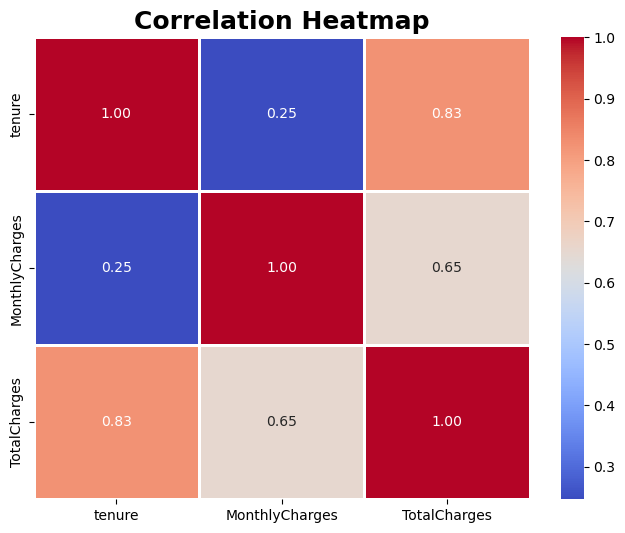

In [48]:
plt.figure(figsize=(8,6))

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1,
    linecolor='white',
    fmt='.2f'
)

plt.title('Correlation Heatmap', fontsize=18, fontweight='bold')

plt.show()

Correlation Heatmap Detailed Observations
--
- TotalCharges and tenure show a very strong positive correlation, meaning total spending increases as customers stay longer with the company.

Higher Tenure ⇒ Higher Total Charges
--

- MonthlyCharges has a moderate positive relationship with TotalCharges, indicating monthly pricing contributes directly to overall customer spending.
- tenure and MonthlyCharges show a weak relationship, meaning customer duration is not strongly dependent on monthly pricing alone.
- The heatmap confirms that customer retention duration is one of the strongest drivers of total revenue generation.
- Strong correlations help identify which variables are most important for churn prediction and revenue analysis.

6. Pairplot for Important Numerical Features
--

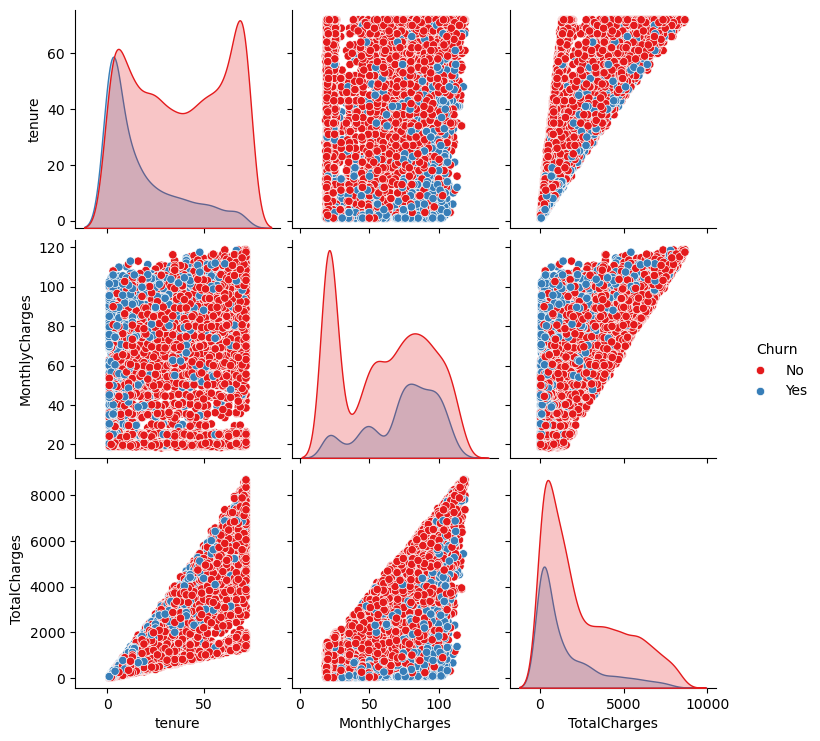

In [49]:
sns.pairplot(
    df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']],
    hue='Churn',
    palette='Set1',
    diag_kind='kde'
)

plt.show()

Pairplot Analysis Detailed Observations
--
- Customers with low tenure and high monthly charges show a stronger tendency to churn.
- Customers with high tenure generally accumulate higher total charges over time.
- Churned customers appear more concentrated in lower tenure regions across multiple plots.
- Retained customers are more widely distributed across higher tenure and total charge ranges.
- The scatter patterns indicate that tenure is one of the strongest indicators of customer loyalty.
- Monthly charges alone do not completely explain churn, but combined with tenure they reveal clearer churn patterns.
- The pairplot highlights visible clustering behavior between churned and retained customers across important numerical features.

# Telco Customer Churn – Exploratory Data Analysis (EDA) Report

## 1. About Dataset

Customer churn is one of the major business challenges in the telecom industry. Churn occurs when customers stop using the company’s services or move to another service provider. This EDA report analyzes customer behavior, service usage, pricing patterns, and contract information to identify the key factors influencing customer churn.

The objective of this analysis is to:

* Understand customer behavior
* Identify important churn drivers
* Detect business risks
* Provide actionable business recommendations

---

# 2. Dataset Overview

| Feature         | Details                         |
| --------------- | ------------------------------- |
| Dataset Name    | Telco Customer Churn Dataset    |
| Total Rows      | 7043                            |
| Total Columns   | 21                              |
| Target Variable | Churn                           |
| Data Type       | Mixed (Categorical + Numerical) |

---

# 3. Data Cleaning Summary

The dataset was mostly clean, but minor preprocessing was required.

### Cleaning Steps Performed

* Converted `TotalCharges` from object datatype to numeric datatype.
* Removed blank values from `TotalCharges`.
* Removed redundant features where necessary.
* Verified missing values and duplicates.

### Why Missing Values Were Removed

* Missing values were very small in number.
* Removing them did not affect the dataset significantly.
* Filling values could introduce unnecessary bias.
* Data quality and reliability were preserved.

---

# 4. Univariate Analysis Summary

## Customer Distribution

* Most customers did not churn.
* However, churned customers still formed a significant customer segment.

## Contract Type

* Month-to-month contracts were the most common.
* Long-term contracts were comparatively fewer.

## Internet Service

* Fiber optic and DSL were the dominant internet services.
* Fiber optic customers formed a major customer group.

## Monthly Charges

* Monthly charges were widely distributed.
* Customers belonged to different pricing segments.
* The median monthly charge was approximately 70.35.

## Total Charges

* Total charges showed a positively skewed distribution.
* Long-term customers contributed higher total revenue.

---

# 5. Bivariate Analysis Summary

## Contract Type vs Churn

### Key Finding

* Month-to-month customers showed the highest churn.
* Long-term contract customers were more stable.

### Business Meaning

Customers with flexible subscriptions are more likely to leave because they are not committed for longer durations.

---

## Tenure vs Churn

### Key Finding

* Customers with lower tenure had higher churn rates.
* Long-term customers were more loyal.

### Business Meaning

Customer loyalty increases with time. New customers are more vulnerable to churn.

---

## Monthly Charges vs Churn

### Key Finding

* Customers paying higher monthly charges showed higher churn behavior.
* Customers with lower charges were relatively more retained.

### Business Meaning

Pricing dissatisfaction may influence customer churn.

---

## Internet Service vs Churn

### Key Finding

* Fiber optic users showed comparatively higher churn.
* Customers without internet service showed lower churn.

### Business Meaning

Premium service customers may have higher expectations regarding quality and pricing.

---

# 6. Multivariate Analysis Summary

## Contract Type + Monthly Charges + Churn

### Observation

* Customers with month-to-month contracts and higher monthly charges showed the highest churn tendency.

### Business Insight

Short-term premium customers are the most at-risk customer group.

---

## Tenure + Internet Service

### Observation

* Fiber optic users were highly concentrated in lower tenure ranges.
* Long-tenure customers appeared more stable.

### Business Insight

Customer retention improves significantly as customer tenure increases.

---

# 7. Payment Method Analysis

## Main Observations

* Electronic check was the most commonly used payment method among churned customers.
* Customers using automatic payment methods appeared more stable.
* Long-term customers preferred automatic payment systems.

## Business Interpretation

Customers using manual payment methods may experience lower convenience and weaker service attachment. Automatic payment methods help improve billing continuity and customer retention.

---

# 8. Correlation Analysis

## Key Relationships

### Tenure vs TotalCharges

* Strong positive correlation observed.
* Customers staying longer generated higher total revenue.

### MonthlyCharges vs TotalCharges

* Moderate positive relationship observed.
* Higher monthly charges contributed to higher total spending.

### Tenure vs MonthlyCharges

* Weak relationship observed.
* Monthly pricing depended more on service plans than customer duration.

---

# 9. Key Findings

## Major Findings from the Analysis

1. Month-to-month customers have the highest churn risk.
2. Low-tenure customers are more likely to leave the company.
3. Higher monthly charges increase churn probability.
4. Fiber optic users show relatively higher churn behavior.
5. Long-term customers contribute significantly higher revenue
